# Name: Gradien Ridholumintu
# NIM: 25/555306/PA/23271

# PCD Assignment 01 - Image Sampling

This notebook implements the following sampling methods manually:

**Down sampling**
- Max
- Average
- Median

**Up sampling**
- Nearest Neighbor
- Bilinear
- Bicubic

We use 10 different images so we can compare the methods on grayscale, RGB, texture, smooth regions, and text. We use a sampling factor of 5 because the differences are easier to see at this scale.

In [10]:
# dependencies
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd()
IMAGE_DIR = ROOT / "images"

DOWNSAMPLE_DIR = ROOT / "results" / "downsampling"
UPSAMPLE_DIR = ROOT / "results" / "upsampling"
COMPARISON_DIR = ROOT / "results" / "comparison"

for folder in (DOWNSAMPLE_DIR, UPSAMPLE_DIR, COMPARISON_DIR):
    folder.mkdir(parents=True, exist_ok=True)

if not IMAGE_DIR.exists():
    raise FileNotFoundError("images/ folder was not found.")

IMAGE_FILES = [
    "brick.png",
    "camera.png",
    "chelsea.png",
    "clock_motion.png",
    "coffee.png",
    "coins.png",
    "moon.png",
    "page.png",
    "rocket.jpg",
    "text.png",
]

FACTOR = 5 # sampling factor

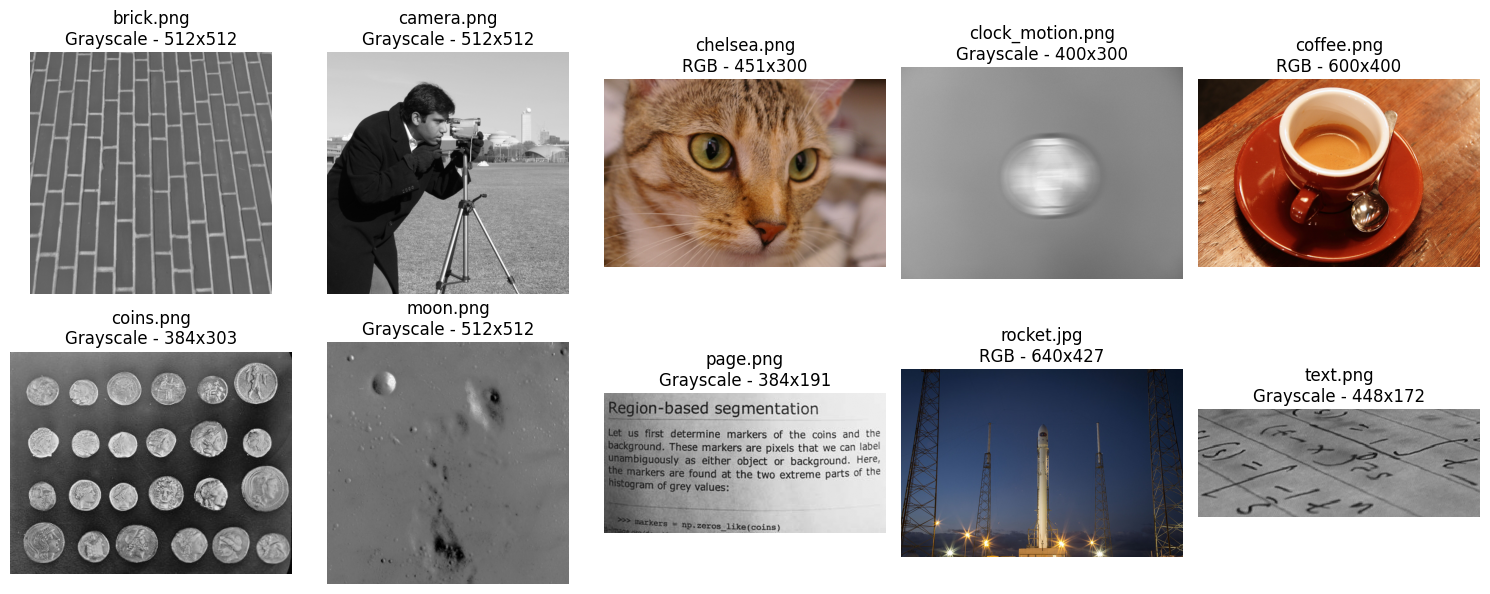

In [11]:
def load_image(filename):
    image = np.array(Image.open(IMAGE_DIR / filename))

    if image.ndim == 3 and image.shape[2] == 4:
        image = image[:, :, :3]

    return image


images = {}

for filename in IMAGE_FILES:
    images[filename] = load_image(filename)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, filename in zip(axes.ravel(), IMAGE_FILES):
    image = images[filename]

    if image.ndim == 2:
        ax.imshow(image, cmap="gray", vmin=0, vmax=255)
        image_type = "Grayscale"
    else:
        ax.imshow(image)
        image_type = "RGB"

    h, w = image.shape[:2]
    ax.set_title(f"{filename}\n{image_type} - {w}x{h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 1. Down Sampling

For down sampling, we divide the image into $s \times s$ blocks. One block produces one output pixel.

- **Max** takes the largest value in the block.
- **Average** calculates the average value in the block.
- **Median** sorts the values and takes the middle value.

For RGB images, we calculate each channel separately.

If the image size is not divisible by the sampling factor, we ignore the incomplete block on the bottom or right side.

In [12]:
def max_downsampling(image, factor):
    h, w = image.shape[:2]
    out_h = h // factor
    out_w = w // factor

    if image.ndim == 2:
        output = np.zeros((out_h, out_w), dtype=np.uint8)
    else:
        output = np.zeros((out_h, out_w, image.shape[2]), dtype=np.uint8)

    for y in range(out_h):
        for x in range(out_w):
            block = image[
                y * factor:(y + 1) * factor,
                x * factor:(x + 1) * factor
            ]

            if image.ndim == 2:
                max_value = int(block[0, 0])

                for by in range(factor):
                    for bx in range(factor):
                        value = int(block[by, bx])
                        if value > max_value:
                            max_value = value

                output[y, x] = max_value

            else:
                for c in range(image.shape[2]):
                    max_value = int(block[0, 0, c])

                    for by in range(factor):
                        for bx in range(factor):
                            value = int(block[by, bx, c])
                            if value > max_value:
                                max_value = value

                    output[y, x, c] = max_value

    return output


def average_downsampling(image, factor):
    h, w = image.shape[:2]
    out_h = h // factor
    out_w = w // factor
    count = factor * factor

    if image.ndim == 2:
        output = np.zeros((out_h, out_w), dtype=np.uint8)
    else:
        output = np.zeros((out_h, out_w, image.shape[2]), dtype=np.uint8)

    for y in range(out_h):
        for x in range(out_w):
            block = image[
                y * factor:(y + 1) * factor,
                x * factor:(x + 1) * factor
            ]

            if image.ndim == 2:
                total = 0

                for by in range(factor):
                    for bx in range(factor):
                        total += int(block[by, bx])

                output[y, x] = round(total / count)

            else:
                for c in range(image.shape[2]):
                    total = 0

                    for by in range(factor):
                        for bx in range(factor):
                            total += int(block[by, bx, c])

                    output[y, x, c] = round(total / count)

    return output


def median_downsampling(image, factor):
    h, w = image.shape[:2]
    out_h = h // factor
    out_w = w // factor

    if image.ndim == 2:
        output = np.zeros((out_h, out_w), dtype=np.uint8)
    else:
        output = np.zeros((out_h, out_w, image.shape[2]), dtype=np.uint8)

    for y in range(out_h):
        for x in range(out_w):
            block = image[
                y * factor:(y + 1) * factor,
                x * factor:(x + 1) * factor
            ]

            if image.ndim == 2:
                values = []

                for by in range(factor):
                    for bx in range(factor):
                        values.append(int(block[by, bx]))

                values.sort()
                n = len(values)

                if n % 2 == 1:
                    median = values[n // 2]
                else:
                    median = (values[n // 2 - 1] + values[n // 2]) / 2

                output[y, x] = round(median)

            else:
                for c in range(image.shape[2]):
                    values = []

                    for by in range(factor):
                        for bx in range(factor):
                            values.append(int(block[by, bx, c]))

                    values.sort()
                    n = len(values)

                    if n % 2 == 1:
                        median = values[n // 2]
                    else:
                        median = (values[n // 2 - 1] + values[n // 2]) / 2

                    output[y, x, c] = round(median)

    return output

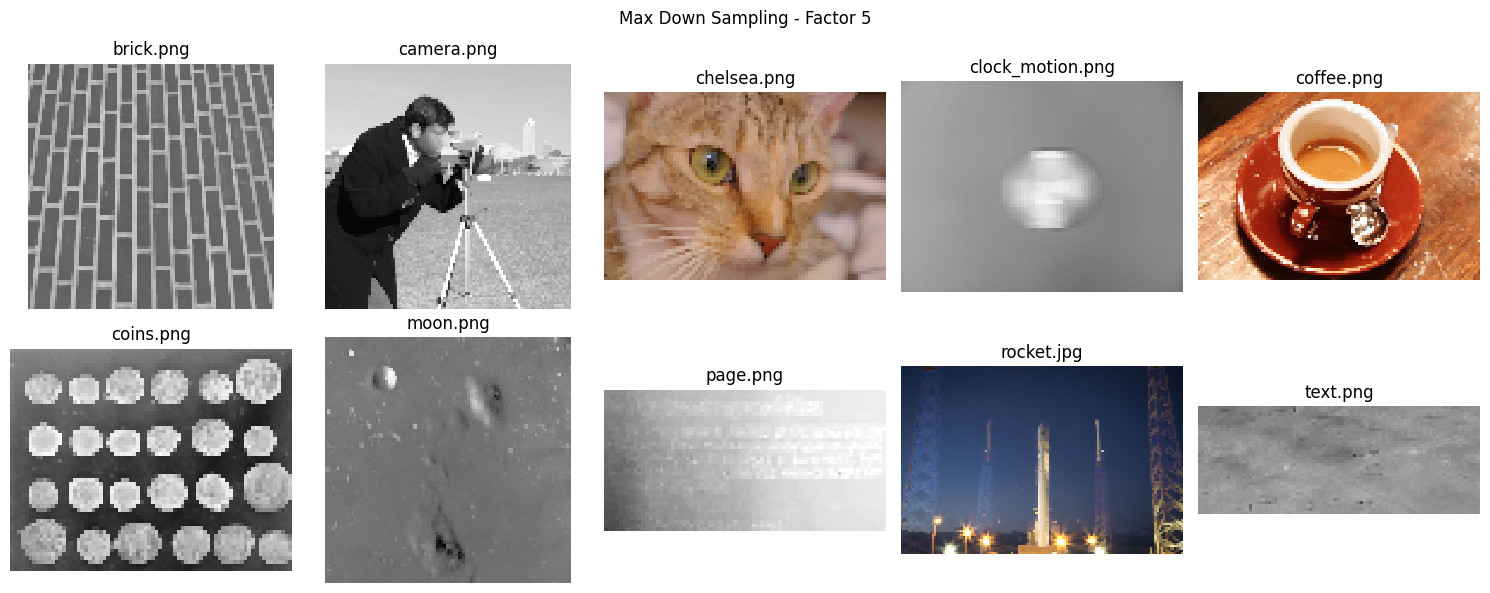

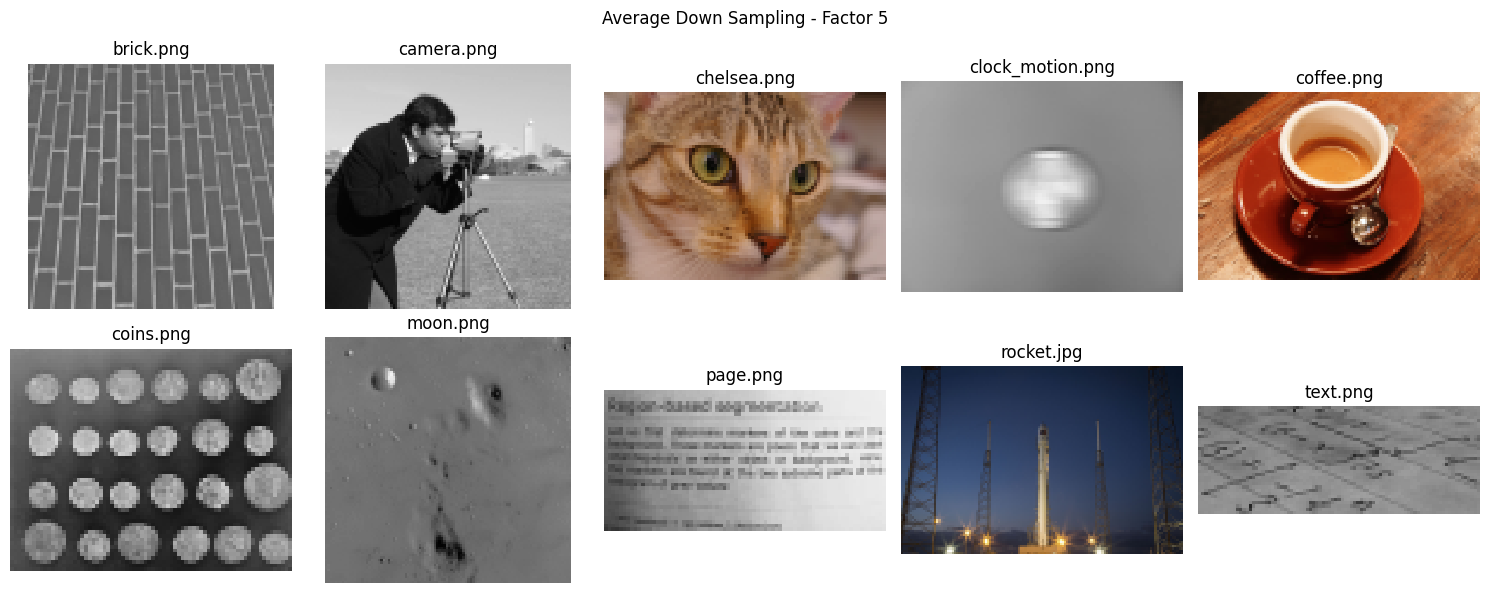

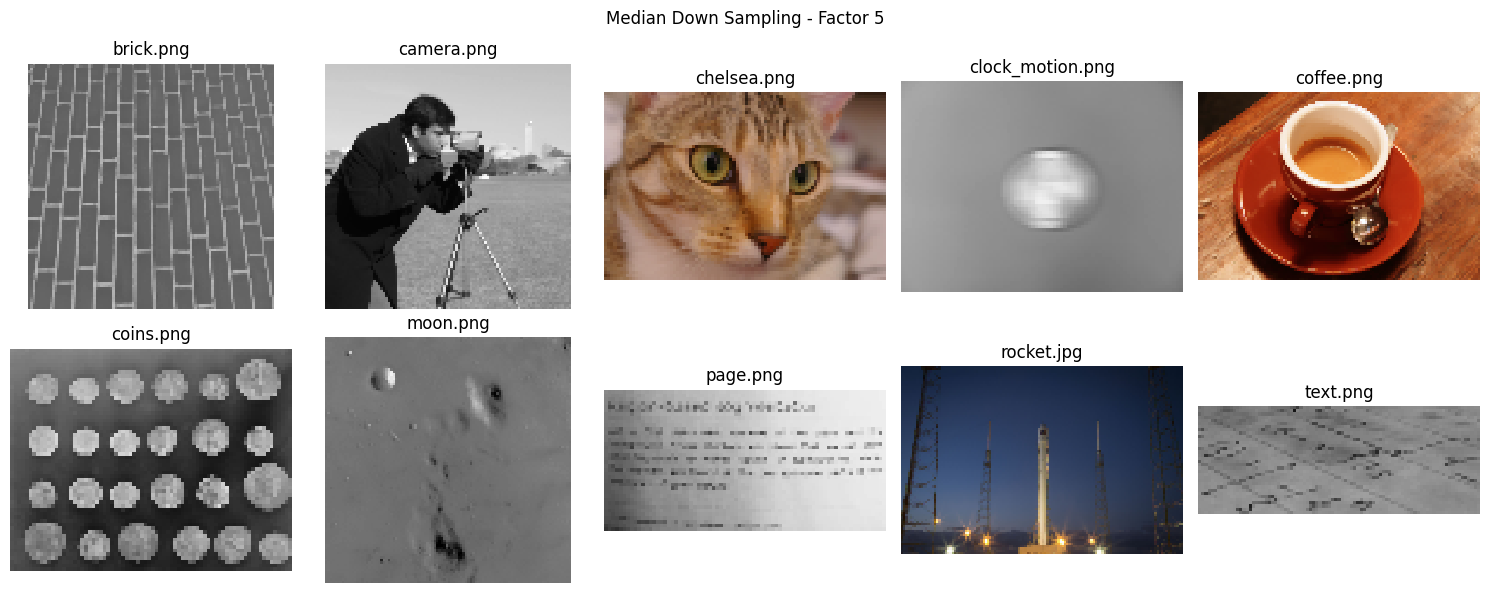

In [13]:
downsample_functions = {
    "max": max_downsampling,
    "average": average_downsampling,
    "median": median_downsampling
}

down_results = {}

# downsample, display and save
for method, function in downsample_functions.items():
    down_results[method] = {}
    method_dir = DOWNSAMPLE_DIR / method
    method_dir.mkdir(exist_ok=True)

    for filename in IMAGE_FILES:
        result = function(images[filename], FACTOR)
        down_results[method][filename] = result

        save_name = Path(filename).stem + ".png"
        Image.fromarray(result).save(method_dir / save_name)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for ax, filename in zip(axes.ravel(), IMAGE_FILES):
        result = down_results[method][filename]

        if result.ndim == 2:
            ax.imshow(result, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        else:
            ax.imshow(result, interpolation="nearest")

        ax.set_title(filename)
        ax.axis("off")

    fig.suptitle(f"{method.title()} Down Sampling - Factor {FACTOR}")
    plt.tight_layout()

    fig.savefig(
        COMPARISON_DIR / f"downsampling_{method}_factor_{FACTOR}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

## 2. Up Sampling

For the up-sampling experiment, we use the Average down-sampled image as the input for all three methods. Instead of making an empty larger image and filling the missing pixels one by one, we map each output position back to the smaller image:

$$
x_s = \frac{x_d}{s}
$$

$$
y_s = \frac{y_d}{s}
$$

We use backward mapping because it is easier to implement. For every output pixel, we just find its position in the source image.

- **Nearest Neighbor** takes one nearest source pixel.
- **Bilinear** calculates the value from the nearest $2 \times 2$ pixels.
- **Bicubic** uses a $4 \times 4$ neighborhood with cubic weights.

In [14]:
def nearest_neighbor(image, factor):
    h, w = image.shape[:2]
    out_h = h * factor
    out_w = w * factor

    if image.ndim == 2:
        output = np.zeros((out_h, out_w), dtype=np.uint8)
    else:
        output = np.zeros((out_h, out_w, image.shape[2]), dtype=np.uint8)

    for y in range(out_h):
        src_y = int(y / factor)

        for x in range(out_w):
            src_x = int(x / factor)
            output[y, x] = image[src_y, src_x]

    return output

def bilinear(image, factor):
    source = image.astype(np.float64)

    h, w = image.shape[:2]
    out_h = h * factor
    out_w = w * factor

    if image.ndim == 2:
        output = np.zeros((out_h, out_w), dtype=np.float64)
    else:
        output = np.zeros((out_h, out_w, image.shape[2]), dtype=np.float64)

    for y in range(out_h):
        src_y = y / factor

        y0 = int(np.floor(src_y))
        y1 = min(y0 + 1, h - 1)
        dy = src_y - y0

        for x in range(out_w):
            src_x = x / factor

            x0 = int(np.floor(src_x))
            x1 = min(x0 + 1, w - 1)
            dx = src_x - x0

            top = (1 - dx) * source[y0, x0] + dx * source[y0, x1]
            bottom = (1 - dx) * source[y1, x0] + dx * source[y1, x1]

            output[y, x] = (1 - dy) * top + dy * bottom

    return np.clip(np.rint(output), 0, 255).astype(np.uint8)

def cubic_weight(distance):
    a = -0.5
    x = abs(distance)

    if x <= 1:
        return (a + 2) * x**3 - (a + 3) * x**2 + 1

    if x < 2:
        return a * x**3 - 5 * a * x**2 + 8 * a * x - 4 * a

    return 0

def bicubic(image, factor):
    source = image.astype(np.float64)

    h, w = image.shape[:2]
    out_h = h * factor
    out_w = w * factor

    if image.ndim == 2:
        output = np.zeros((out_h, out_w), dtype=np.float64)
    else:
        output = np.zeros((out_h, out_w, image.shape[2]), dtype=np.float64)

    for y in range(out_h):
        src_y = y / factor
        y_base = int(np.floor(src_y))

        for x in range(out_w):
            src_x = x / factor
            x_base = int(np.floor(src_x))

            if image.ndim == 2:
                value = 0.0
            else:
                value = np.zeros(image.shape[2], dtype=np.float64)

            # bicubic uses a 4x4 neighborhood
            for m in range(-1, 3):
                yy = min(max(y_base + m, 0), h - 1)
                wy = cubic_weight(src_y - (y_base + m))

                for n in range(-1, 3):
                    xx = min(max(x_base + n, 0), w - 1)
                    wx = cubic_weight(src_x - (x_base + n))

                    value += source[yy, xx] * wy * wx

            output[y, x] = value

    return np.clip(np.rint(output), 0, 255).astype(np.uint8)

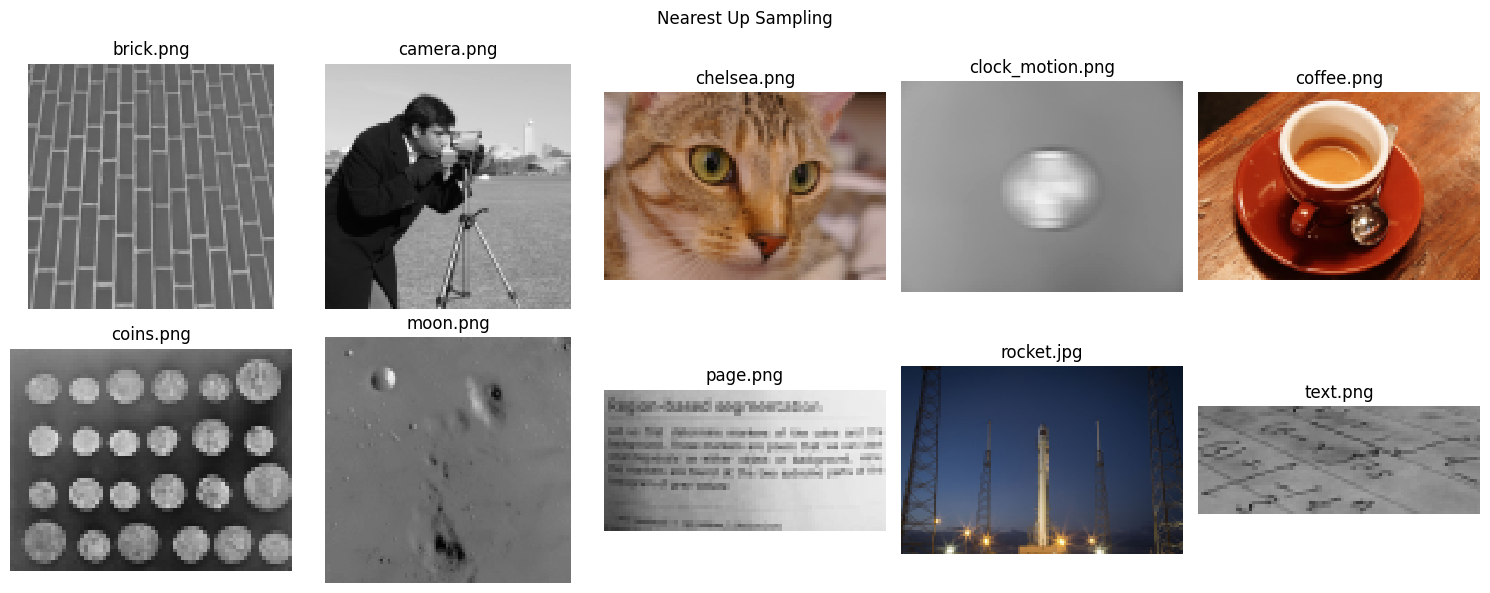

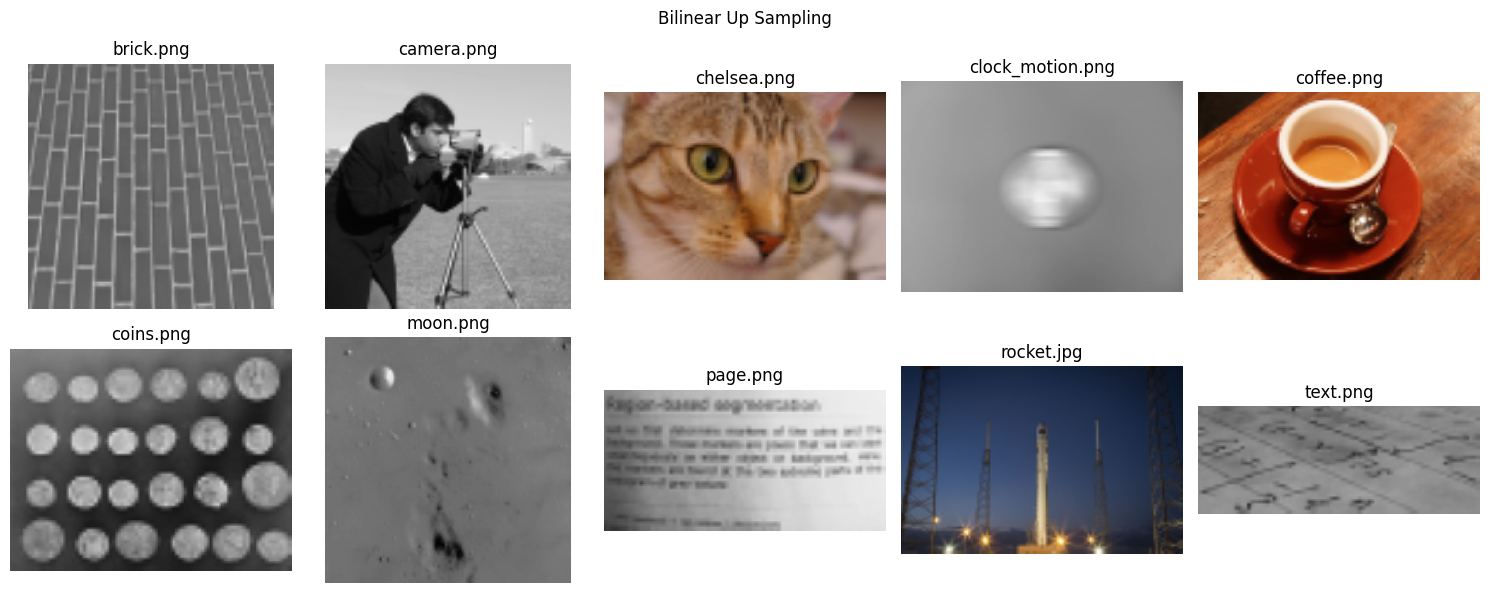

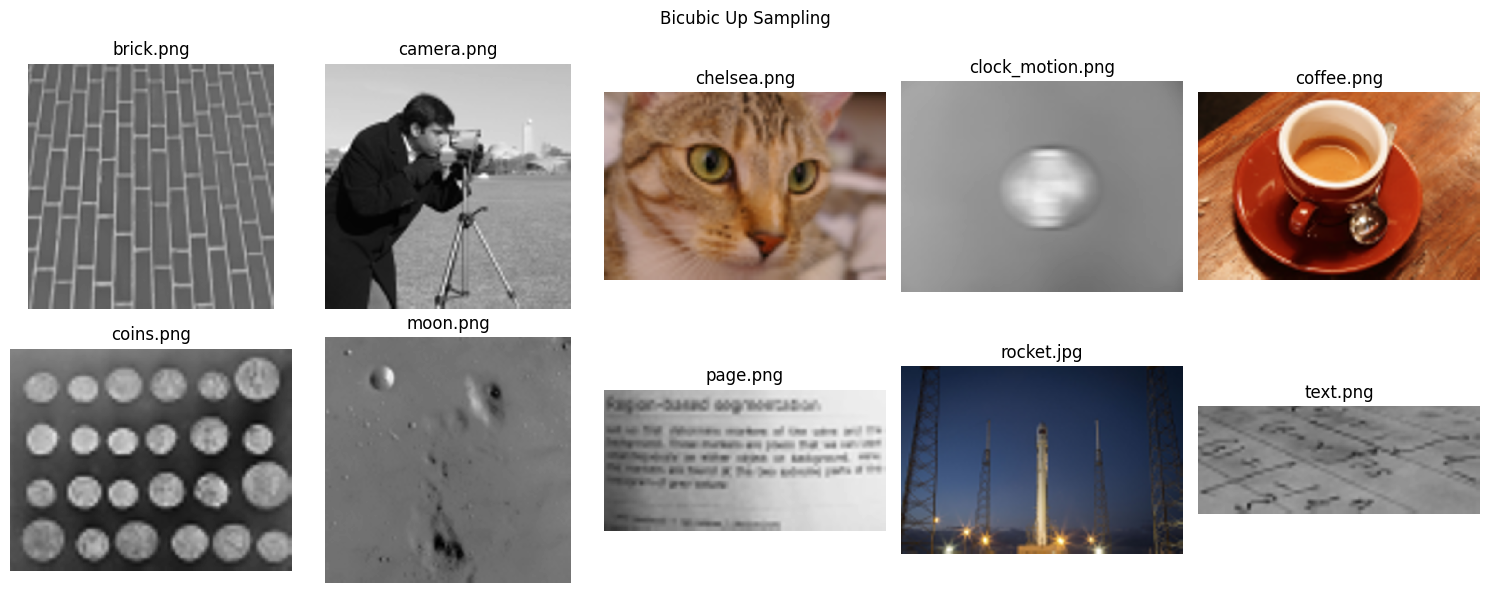

In [15]:
upsample_functions = {
    "nearest": nearest_neighbor,
    "bilinear": bilinear,
    "bicubic": bicubic
}

# use the same low-resolution input for a fair comparison
low_res_images = down_results["average"]

up_results = {}

# upsample, save, and display results
for method, function in upsample_functions.items():
    up_results[method] = {}
    method_dir = UPSAMPLE_DIR / method
    method_dir.mkdir(exist_ok=True)

    for filename in IMAGE_FILES:
        result = function(low_res_images[filename], FACTOR)
        up_results[method][filename] = result

        save_name = Path(filename).stem + ".png"
        Image.fromarray(result).save(method_dir / save_name)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for ax, filename in zip(axes.ravel(), IMAGE_FILES):
        result = up_results[method][filename]

        if result.ndim == 2:
            ax.imshow(result, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        else:
            ax.imshow(result, interpolation="nearest")

        ax.set_title(filename)
        ax.axis("off")

    fig.suptitle(f"{method.title()} Up Sampling")
    plt.tight_layout()

    fig.savefig(
        COMPARISON_DIR / f"upsampling_{method}_factor_{FACTOR}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

## 3. Side-by-side Comparison

The following examples make the differences easier to see. `page.png` is useful for checking text and edges, while `brick.png` is useful for repeated texture.


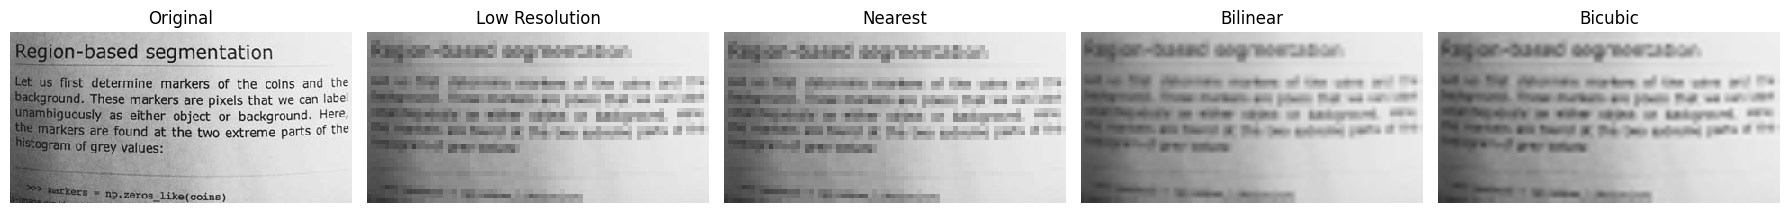

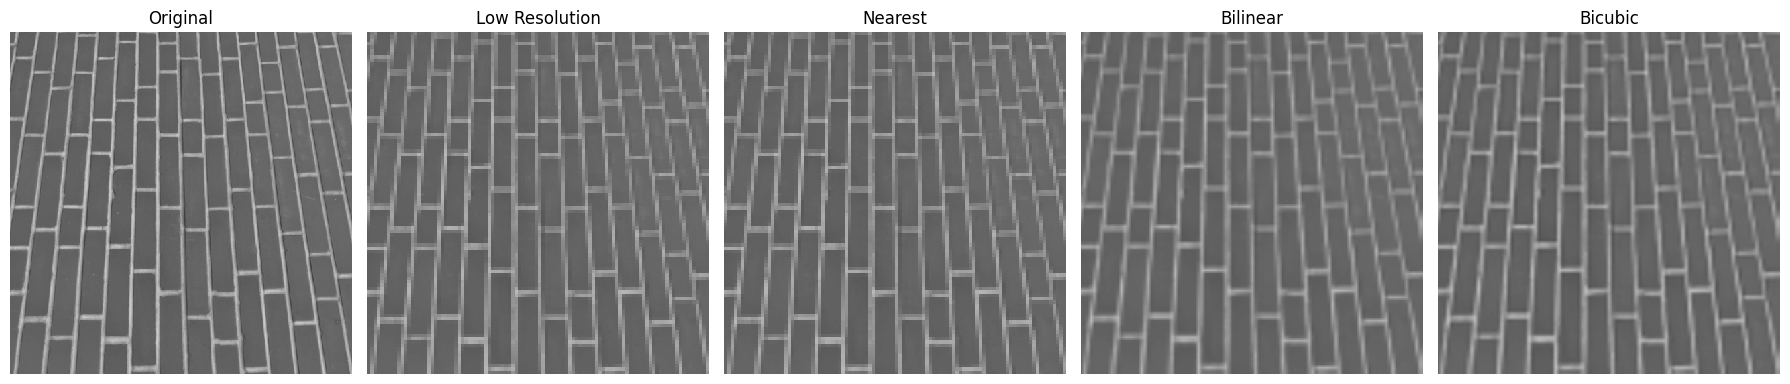

In [16]:
for filename in ("page.png", "brick.png"):
    original = images[filename]

    # down sampling may ignore the last incomplete block
    h = (original.shape[0] // FACTOR) * FACTOR
    w = (original.shape[1] // FACTOR) * FACTOR
    original = original[:h, :w]

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    items = [
        ("Original", original),
        ("Low Resolution", low_res_images[filename]),
        ("Nearest", up_results["nearest"][filename]),
        ("Bilinear", up_results["bilinear"][filename]),
        ("Bicubic", up_results["bicubic"][filename]),
    ]

    for ax, (title, image) in zip(axes, items):
        if image.ndim == 2:
            ax.imshow(image, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        else:
            ax.imshow(image, interpolation="nearest")

        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()

    save_name = Path(filename).stem
    fig.savefig(
        COMPARISON_DIR / f"{save_name}_upsampling_comparison.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

## 4. MSE Comparison

We also calculate Mean Squared Error (MSE) to compare the reconstructed image with the original image.

$$
MSE = \frac{1}{N}\sum_{i=1}^{N}(I_i-K_i)^2
$$

A smaller MSE means the reconstructed image is numerically closer to the original. For the down-sampling comparison, we enlarge Max, Average, and Median using the same Bicubic method before calculating MSE.

For the up-sampling comparison, all three methods use the same Average down-sampled image.

In [17]:
def mse(original, reconstructed):
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)
    return np.mean((original - reconstructed) ** 2)

def crop_original(image, factor):
    h = (image.shape[0] // factor) * factor
    w = (image.shape[1] // factor) * factor
    return image[:h, :w]

# Down-sampling MSE:
# use the same Bicubic reconstruction for all three methods
down_mse = {}

for method in ("max", "average", "median"):
    down_mse[method] = {}

    for filename in IMAGE_FILES:
        original = crop_original(images[filename], FACTOR)

        if method == "average":
            # this result was already calculated in the up-sampling section
            reconstructed = up_results["bicubic"][filename]
        else:
            reconstructed = bicubic(down_results[method][filename], FACTOR)

        down_mse[method][filename] = mse(original, reconstructed)

print("DOWN SAMPLING MSE")
print(f"{'Image':18s} {'Max':>12s} {'Average':>12s} {'Median':>12s}")
print("-" * 58)

for filename in IMAGE_FILES:
    print(
        f"{filename:18s} "
        f"{down_mse['max'][filename]:12.3f} "
        f"{down_mse['average'][filename]:12.3f} "
        f"{down_mse['median'][filename]:12.3f}"
    )

print("-" * 58)

for method in ("max", "average", "median"):
    average_mse = np.mean(list(down_mse[method].values()))
    print(f"Average {method:7s} MSE: {average_mse:.3f}")

DOWN SAMPLING MSE
Image                       Max      Average       Median
----------------------------------------------------------
brick.png               838.202      352.151      370.394
camera.png             1088.379      381.697      420.249
chelsea.png             504.090      163.650      170.002
clock_motion.png         26.932       12.613       15.079
coffee.png             1316.765      351.788      375.170
coins.png              1924.990      616.170      700.796
moon.png                 71.157       23.062       24.250
page.png               2272.446     1095.638     1219.718
rocket.jpg              674.998      176.414      191.148
text.png                684.528      284.930      304.748
----------------------------------------------------------
Average max     MSE: 940.249
Average average MSE: 345.811
Average median  MSE: 379.155


In [18]:
# Up-sampling MSE:
# all methods use the same Average-downsampled input
up_mse = {}

for method in ("nearest", "bilinear", "bicubic"):
    up_mse[method] = {}

    for filename in IMAGE_FILES:
        original = crop_original(images[filename], FACTOR)
        reconstructed = up_results[method][filename]
        up_mse[method][filename] = mse(original, reconstructed)

print("UP SAMPLING MSE")
print(f"{'Image':18s} {'Nearest':>12s} {'Bilinear':>12s} {'Bicubic':>12s}")
print("-" * 58)

for filename in IMAGE_FILES:
    print(
        f"{filename:18s} "
        f"{up_mse['nearest'][filename]:12.3f} "
        f"{up_mse['bilinear'][filename]:12.3f} "
        f"{up_mse['bicubic'][filename]:12.3f}"
    )

print("-" * 58)

for method in ("nearest", "bilinear", "bicubic"):
    average_mse = np.mean(list(up_mse[method].values()))
    print(f"Average {method:8s} MSE: {average_mse:.3f}")

UP SAMPLING MSE
Image                   Nearest     Bilinear      Bicubic
----------------------------------------------------------
brick.png               236.605      352.739      352.151
camera.png              256.873      377.469      381.697
chelsea.png             112.239      164.383      163.650
clock_motion.png          6.414       12.508       12.613
coffee.png              263.607      351.466      351.788
coins.png               436.395      615.130      616.170
moon.png                 18.155       23.472       23.062
page.png                955.192     1089.476     1095.638
rocket.jpg              147.002      175.377      176.414
text.png                209.604      283.125      284.930
----------------------------------------------------------
Average nearest  MSE: 264.209
Average bilinear MSE: 344.514
Average bicubic  MSE: 345.811


## 5. Observation

From the down-sampling results, Average and Median look more similar to the original image than Max. Max often makes bright areas more dominant because it only keeps the highest value from each block.
The MSE results also show this. The average MSE is:

- Max: **940.249**
- Average: **345.811**
- Median: **379.155**

So for these images, Average gives the smallest error.

The difference also depends on the image. `clock_motion.png` has a very small error because most of the image changes smoothly. `page.png` has a much larger error because it contains small text and sharp edges that are easily lost when we reduce the resolution by a factor of 5.

For up sampling, Nearest Neighbor looks the most blocky, while Bilinear and Bicubic look smoother. However, Nearest Neighbor gives the smallest MSE in our experiment:

- Nearest Neighbor: **264.209**
- Bilinear: **344.514**
- Bicubic: **345.811**

One reason Nearest Neighbor performs better here is that our low-resolution image was made using Average down sampling. Each low-resolution pixel represents the average of one block, and Nearest Neighbor repeats this value when enlarging it again.

So in this experiment, smaller MSE does not always mean the image looks smoother. Nearest Neighbor has the smallest numerical error, but Bilinear and Bicubic produce smoother-looking results. The loss of detail is easiest to see in `page.png` and `brick.png`. After down sampling by a factor of 5, some information is already lost, so up sampling cannot completely reconstruct the original image.